In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.ticker as tck
import pandas as pd

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.set_default_device(DEVICE)

In [2]:
torch.sech = lambda z: 1.0 / torch.cosh(z)

def analytical_KdV(concat_tensor, beta_):
    if not isinstance(beta_, torch.Tensor):
        beta_ = torch.tensor(beta_, dtype=torch.float32)

    t, x = concat_tensor[:, 0], concat_tensor[:, 1]
    return torch.pow(torch.sech((x-t/3)/torch.sqrt(12*beta_)), 2)  

In [3]:
x_bound = 1
x_bound_t_low = torch.tensor(-x_bound, dtype=torch.float32)
x_bound_t_up = torch.tensor(x_bound, dtype=torch.float32)

t_bound = 1
t_bound_t_low = torch.tensor(0, dtype=torch.float32)
t_bound_t_up = torch.tensor(t_bound, dtype=torch.float32)

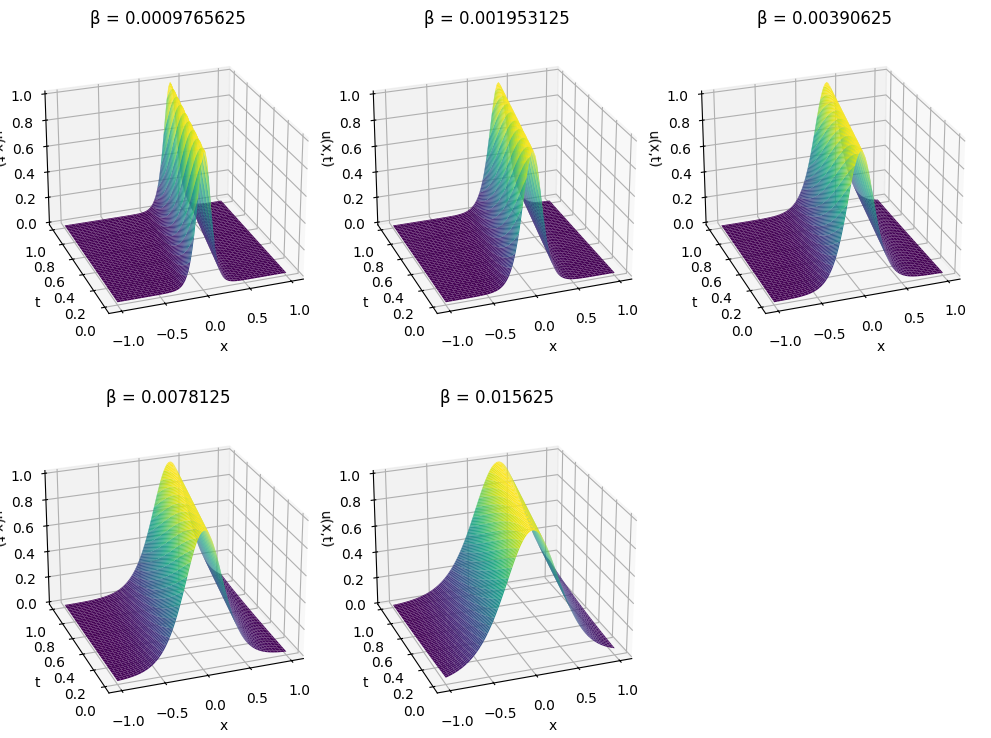

In [4]:
# Create grid for t and x
t_vals = np.linspace(t_bound_t_low, t_bound_t_up, 100)
x_vals = np.linspace(x_bound_t_low, x_bound_t_up, 100)
T, X = np.meshgrid(t_vals, x_vals)

# Prepare input tensor for analytical_KdV
grid_points = np.column_stack((T.ravel(), X.ravel()))
concat_tensor = torch.tensor(grid_points, dtype=torch.float32)

# Set up the figure and axes for 2x2 subplots
fig = plt.figure(figsize=(10, 8))
betas = [2**-10, 2**-9, 2**-8, 2**-7, 2**-6]
axes = []

for i, beta_val in enumerate(betas, start=1):
    ax = fig.add_subplot(2,3,i, projection='3d')
    axes.append(ax)
    # Compute u values for current beta
    u_vals = analytical_KdV(concat_tensor, beta_val).detach().numpy()
    U = u_vals.reshape(X.shape)
    # Plot surface
    surf = ax.plot_surface(X,T, U, cmap='viridis')
    ax.set_title(f'β = {beta_val}')
    ax.set_xlabel('x')
    ax.set_ylabel('t')
    ax.set_zlabel('u(x,t)')
    # Adjust view if needed
    ax.view_init(elev=25, azim=250)

plt.tight_layout()
plt.show()

## Model Training

In [5]:
class FCN(nn.Module):
    "Defines a connected network"
    
    def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN, N_LAYERS, init_type='he_normal'):
        super().__init__()
        activation = nn.SiLU()
        #activation = nn.CELU()
        #activation = nn.LeakyReLU(negative_slope=0.1)
        #activation = nn.Tanh()
        self.fcs = nn.Sequential(*[
                        nn.Linear(N_INPUT, N_HIDDEN),
                        activation])
        self.fch = nn.Sequential(*[
                        nn.Sequential(*[
                            #nn.BatchNorm1d(N_HIDDEN),
                            nn.Linear(N_HIDDEN, N_HIDDEN),
                            activation]) for _ in range(N_LAYERS-1)])
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)

        # Initialize weights
        self._initialize_weights(init_type)
    
    def _initialize_weights(self, init_type):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                if init_type == 'xavier_uniform':
                    torch.nn.xavier_uniform_(module.weight)
                elif init_type == 'xavier_normal':
                    torch.nn.init.xavier_normal_(module.weight)
                elif init_type == 'he_uniform':
                    torch.nn.init.kaiming_uniform_(module.weight, nonlinearity='relu')
                elif init_type == 'he_normal':
                    torch.nn.init.kaiming_normal_(module.weight, nonlinearity='relu')
                elif init_type == 'orthogonal':
                    torch.nn.init.orthogonal_(module.weight)
                elif init_type == 'unit_normal':
                    torch.nn.init.normal_(module.weight)
                else:
                    raise ValueError(f"Unknown initialization type: {init_type}")
                
                if module.bias is not None:
                    torch.nn.init.constant_(module.bias, 0.0)

    def forward(self, x):
        x = self.fcs(x)
        x = self.fch(x)
        x = self.fce(x)
        return x

### Loss funcs.

In [6]:
def KdV_loss(model, T, X, beta_):
    if not isinstance(beta_, torch.Tensor):
        beta_ = torch.tensor(beta_, dtype=torch.float32)
    
    u = model(torch.cat((T, X), dim=1))
    u_t = torch.autograd.grad(u, T, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, X, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, X, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    u_xxx = torch.autograd.grad(u_xx, X, grad_outputs=torch.ones_like(u_xx), create_graph=True)[0]
    return torch.mean((u_t + u*u_x + beta_*u_xxx) ** 2)

In [7]:
# Initial and boundary conditions
def initial_condition_loss(model, x, beta_):
    
    if not isinstance(beta_, torch.Tensor):
        beta_ = torch.tensor(beta_, dtype=torch.float32)
        
    t0 = torch.zeros_like(x)
    u = model(torch.cat((t0, x), dim=1))
    u0 = torch.pow(torch.sech(x/torch.sqrt(12*beta_)), 2)
    return torch.mean((u - u0) ** 2)

# def boundary_condition_loss_wave(model, x):
#     t0 = torch.zeros_like(x,requires_grad=True)
#     u_t = torch.autograd.grad(model(torch.cat((t0, x), dim=1)), t0, grad_outputs=torch.ones_like(x), create_graph=True)[0]
#     return torch.mean(u_t ** 2)

In [8]:
def collocation_loss(model, n_points, beta_):
    #torch.manual_seed(2025)
    #torch.rand((n_points, 1)) 

    # Generate evenly spaced points for t and x
    t_vals = torch.linspace(t_bound_t_low, t_bound_t_up, n_points, requires_grad=True)
    x_vals = torch.linspace(x_bound_t_low, x_bound_t_up, n_points, requires_grad=True)

    t_vals, x_vals = torch.meshgrid(t_vals, x_vals)
    
    t_vals = t_vals.flatten().unsqueeze(1)
    x_vals = x_vals.flatten().unsqueeze(1)
    
    # Flatten and concatenate t and x for input to the model
    input_t = torch.cat((t_vals, x_vals), dim=1)
    
    # Compute the collocation loss
    loss = torch.mean((model(input_t) - analytical_KdV(input_t,beta_))**2)
    return loss

In [9]:
# Training process
w_phy = 100
num_epochs = 750

def train_pinn(model, optimizer, epochs, t, x, beta_):
    for epoch in range(epochs):
        optimizer.zero_grad()
        loss = w_phy*KdV_loss(model, t, x, beta_) \
             + initial_condition_loss(model, x, beta_)\
             + collocation_loss(model, 32, beta_)
        loss.backward()
        optimizer.step()

        if epochs%100==0:
            print_gap = 100
        elif epochs%125==0:
            print_gap = 125

        if (epoch+1) % print_gap == 0 or epoch==0:
            print(f"Epoch {epoch+1}, Loss: {loss.item():.6f}")

# Define the domain
t = torch.linspace(t_bound_t_low, t_bound_t_up, 100)#.requires_grad_()
x = torch.linspace(x_bound_t_low, x_bound_t_up, 100)#.requires_grad_()

t, x = torch.meshgrid(t, x)
t = t.flatten().unsqueeze(1).requires_grad_()  
x = x.flatten().unsqueeze(1).requires_grad_()

c:\Users\jazzo\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4312.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [10]:
state_dict_fp = r"C:\Users\jazzo\Desktop\academics\Oxford\MSc\MT\Theories of Deep Learning\miniproj\code\python\state_dicts\KdV\w=100,ep=750\\"

beta_values = [2**-10, 2**-9, 2**-8, 2**-7, 2**-6]


### Conventional

In [ ]:

conv_models = {}

print(f'w_phy={w_phy}')

for beta in beta_values:
    print(f"Training for beta = {beta}")
    model = FCN(2,1,75, 6)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    train_pinn(model, optimizer, num_epochs, t, x, beta)
    print(f"Finished training for beta = {beta}\n")
    conv_models[beta] = model
    

w_phy=100
Training for beta = 0.0009765625
Epoch 1, Loss: 125.858582
Epoch 125, Loss: 0.141108
Epoch 250, Loss: 0.124287
Epoch 375, Loss: 0.118603
Epoch 500, Loss: 0.115340
Epoch 625, Loss: 0.113466
Epoch 750, Loss: 0.112422
Finished training for beta = 0.0009765625

Training for beta = 0.001953125
Epoch 1, Loss: 553.077637
Epoch 125, Loss: 0.216383
Epoch 250, Loss: 0.184847
Epoch 375, Loss: 0.171848
Epoch 500, Loss: 0.162832
Epoch 625, Loss: 0.155795
Epoch 750, Loss: 0.150427
Finished training for beta = 0.001953125

Training for beta = 0.00390625
Epoch 1, Loss: 10.264075
Epoch 125, Loss: 0.190105
Epoch 250, Loss: 0.175802
Epoch 375, Loss: 0.169331
Epoch 500, Loss: 0.167251
Epoch 625, Loss: 0.165732
Epoch 750, Loss: 0.163981
Finished training for beta = 0.00390625

Training for beta = 0.0078125
Epoch 1, Loss: 7.823464
Epoch 125, Loss: 0.228820
Epoch 250, Loss: 0.193551
Epoch 375, Loss: 0.184504
Epoch 500, Loss: 0.180469
Epoch 625, Loss: 0.177748
Epoch 750, Loss: 0.175996
Finished trai

In [16]:
for beta in beta_values:
    beta_power = int(np.log2(beta))
    torch.save(conv_models[beta].state_dict(), state_dict_fp + f"conven_beta=2^{beta_power}.pth")

### Transfer Learning (init.)

In [17]:
source_conven_state = torch.load(state_dict_fp + "conven_beta=2^-6.pth", weights_only=True)

In [18]:
TL_init_models_6 = {}

for beta in beta_values:
    print(f"Training for beta = {beta}")
    model = FCN(2,1,75,6)
    model.load_state_dict(source_conven_state)
    model.eval()
    
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    train_pinn(model, optimizer, num_epochs, t, x, beta)
    print(f"Finished training for beta = {beta}\n")
    TL_init_models_6[beta] = model

Training for beta = 0.0009765625


Epoch 1, Loss: 1.000920
Epoch 125, Loss: 0.109446
Epoch 250, Loss: 0.108259
Epoch 375, Loss: 0.107576
Epoch 500, Loss: 0.106742
Epoch 625, Loss: 0.105713
Epoch 750, Loss: 0.104765
Finished training for beta = 0.0009765625

Training for beta = 0.001953125
Epoch 1, Loss: 0.876679
Epoch 125, Loss: 0.136811
Epoch 250, Loss: 0.135644
Epoch 375, Loss: 0.134503
Epoch 500, Loss: 0.132953
Epoch 625, Loss: 0.131120
Epoch 750, Loss: 0.129294
Finished training for beta = 0.001953125

Training for beta = 0.00390625
Epoch 1, Loss: 0.672274
Epoch 125, Loss: 0.161891
Epoch 250, Loss: 0.159782
Epoch 375, Loss: 0.157926
Epoch 500, Loss: 0.156077
Epoch 625, Loss: 0.153555
Epoch 750, Loss: 0.149829
Finished training for beta = 0.00390625

Training for beta = 0.0078125
Epoch 1, Loss: 0.379963
Epoch 125, Loss: 0.174437
Epoch 250, Loss: 0.171296
Epoch 375, Loss: 0.169720
Epoch 500, Loss: 0.167987
Epoch 625, Loss: 0.165755
Epoch 750, Loss: 0.163944
Finished training for beta = 0.0078125

Training for beta = 0

In [19]:
for beta in beta_values:
    beta_power = int(np.log2(beta))
    torch.save(TL_init_models_6[beta].state_dict(), state_dict_fp + f"TL_init_source=2^-6_beta=2^{beta_power}.pth")

### Transfer Learning (fixed)

In [23]:
source_conven_state = torch.load(state_dict_fp + "conven_beta=2^-6.pth", weights_only=True)

In [24]:
TL_fixed_models_6 = {}

print(w_phy)
print(num_epochs)
print(beta_values)

for beta in beta_values:
    print(f"Training for beta = {beta}")
    model = FCN(2,1,75,6)
    model.load_state_dict(source_conven_state)
    model.eval()

    params = list(model.named_parameters())
    midpoint = len(params) // 2 - 1
    for i, (name, param) in enumerate(params):
        if i < midpoint:
            param.requires_grad = False

    # Verify which layers are frozen
    for name, param in model.named_parameters():
        print(f"{name}: requires_grad={param.requires_grad}")

    model.eval()

    # Define the optimizer for the unfrozen parameters
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), 
        lr=1e-3)
    train_pinn(model, optimizer, num_epochs, t, x, beta)

    print(f"Finished training for beta = {beta}\n")
    TL_fixed_models_6[beta] = model

100
750
[0.0009765625, 0.001953125, 0.00390625, 0.0078125, 0.015625]
Training for beta = 0.0009765625
fcs.0.weight: requires_grad=False
fcs.0.bias: requires_grad=False
fch.0.0.weight: requires_grad=False
fch.0.0.bias: requires_grad=False
fch.1.0.weight: requires_grad=False
fch.1.0.bias: requires_grad=False
fch.2.0.weight: requires_grad=True
fch.2.0.bias: requires_grad=True
fch.3.0.weight: requires_grad=True
fch.3.0.bias: requires_grad=True
fch.4.0.weight: requires_grad=True
fch.4.0.bias: requires_grad=True
fce.weight: requires_grad=True
fce.bias: requires_grad=True


Epoch 1, Loss: 1.000920
Epoch 125, Loss: 0.109957
Epoch 250, Loss: 0.108789
Epoch 375, Loss: 0.108102
Epoch 500, Loss: 0.107385
Epoch 625, Loss: 0.106633
Epoch 750, Loss: 0.105961
Finished training for beta = 0.0009765625

Training for beta = 0.001953125
fcs.0.weight: requires_grad=False
fcs.0.bias: requires_grad=False
fch.0.0.weight: requires_grad=False
fch.0.0.bias: requires_grad=False
fch.1.0.weight: requires_grad=False
fch.1.0.bias: requires_grad=False
fch.2.0.weight: requires_grad=True
fch.2.0.bias: requires_grad=True
fch.3.0.weight: requires_grad=True
fch.3.0.bias: requires_grad=True
fch.4.0.weight: requires_grad=True
fch.4.0.bias: requires_grad=True
fce.weight: requires_grad=True
fce.bias: requires_grad=True
Epoch 1, Loss: 0.876679
Epoch 125, Loss: 0.137482
Epoch 250, Loss: 0.136328
Epoch 375, Loss: 0.135352
Epoch 500, Loss: 0.134311
Epoch 625, Loss: 0.133301
Epoch 750, Loss: 0.132344
Finished training for beta = 0.001953125

Training for beta = 0.00390625
fcs.0.weight: requires

In [25]:
for beta in beta_values:
    beta_power = int(np.log2(beta))
    torch.save(TL_fixed_models_6[beta].state_dict(), state_dict_fp + f"TL_fixed_source=2^-6_beta=2^{beta_power}.pth")

### Meta-learning (MAML)

In [ ]:
def train_metalearner(model, optimizer, epochs, t, x):
    for epoch in range(epochs):
        optimizer.zero_grad()
        loss = 0
        for beta in beta_values:
            loss += w_phy*KdV_loss(model, t, x, beta)\
                  + initial_condition_loss(model, x, beta)\
                  + collocation_loss(model, 32, beta)
        
        loss.backward()
        optimizer.step()

        if epochs%100==0:
            print_gap = 100
        elif epochs%125==0:
            print_gap = 125

        if (epoch+1) % print_gap == 0 or epoch==0:
            print(f"Epoch {epoch+1}, Loss: {loss.item():.6f}")

MAML_metalearner = FCN(2,1,75,6)
optimizer = torch.optim.Adam(MAML_metalearner.parameters(), lr=1e-3)
train_metalearner(MAML_metalearner, optimizer, num_epochs, t, x)

Epoch 1, Loss: 1059.100098
Epoch 125, Loss: 1.682073
Epoch 250, Loss: 1.185051
Epoch 375, Loss: 1.050344
Epoch 500, Loss: 0.994760
Epoch 625, Loss: 0.962350
Epoch 750, Loss: 0.943540


In [30]:
torch.save(MAML_metalearner.state_dict(), state_dict_fp + "MAML.pth")
MAML_state = torch.load(state_dict_fp + "MAML.pth", weights_only=True)

In [ ]:
meta_models = {}

for beta in beta_values:
    print(f"Training for beta = {beta}")
    model = FCN(2,1,75,6)
    model.load_state_dict(MAML_state)
    model.eval()

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    train_pinn(model, optimizer, num_epochs, t, x, beta)
    print(f"Finished training for beta = {beta}\n")
    meta_models[beta] = model

Training for beta = 0.0009765625
Epoch 1, Loss: 0.140203
Epoch 125, Loss: 0.111496
Epoch 250, Loss: 0.110661
Epoch 375, Loss: 0.110003
Epoch 500, Loss: 0.109279
Epoch 625, Loss: 0.108527
Epoch 750, Loss: 0.107728
Finished training for beta = 0.0009765625

Training for beta = 0.001953125
Epoch 1, Loss: 0.154002
Epoch 125, Loss: 0.142082
Epoch 250, Loss: 0.140020
Epoch 375, Loss: 0.138615
Epoch 500, Loss: 0.137286
Epoch 625, Loss: 0.136097
Epoch 750, Loss: 0.134585
Finished training for beta = 0.001953125

Training for beta = 0.00390625
Epoch 1, Loss: 0.174706
Epoch 125, Loss: 0.171632
Epoch 250, Loss: 0.167313
Epoch 375, Loss: 0.164273
Epoch 500, Loss: 0.161864
Epoch 625, Loss: 0.159195
Epoch 750, Loss: 0.153442
Finished training for beta = 0.00390625

Training for beta = 0.0078125
Epoch 1, Loss: 0.207840
Epoch 125, Loss: 0.192447
Epoch 250, Loss: 0.184020
Epoch 375, Loss: 0.177082
Epoch 500, Loss: 0.172817
Epoch 625, Loss: 0.170173
Epoch 750, Loss: 0.166879
Finished training for beta =

In [32]:
for beta in beta_values:
    beta_power = int(np.log2(beta))
    torch.save(meta_models[beta].state_dict(), state_dict_fp + f"meta_beta=2^{beta_power}.pth")

### Multi-task learning

In [11]:
MTL_models = {}

print(w_phy)
print(num_epochs)
print(beta_values)

for beta in beta_values:
    print(f"Training for beta = {beta}")
    model = FCN(2,1,75,6)
    model.load_state_dict(MAML_state)
    model.eval()

    params = list(model.named_parameters())
    midpoint = len(params) // 2 - 1
    for i, (name, param) in enumerate(params):
        if i < midpoint:
            param.requires_grad = False

    # Verify which layers are frozen
    for name, param in model.named_parameters():
        print(f"{name}: requires_grad={param.requires_grad}")

    model.eval()

    # Define the optimizer for the unfrozen parameters
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), 
        lr=1e-3)
    train_pinn(model, optimizer, num_epochs, t, x, beta)

    print(f"Finished training for beta = {beta}\n")
    MTL_models[beta] = model

100
750
[0.0009765625, 0.001953125, 0.00390625, 0.0078125, 0.015625]
Training for beta = 0.0009765625


NameError: name 'MAML_state' is not defined

In [34]:
for beta in beta_values:
    beta_power = int(np.log2(beta))
    torch.save(MTL_models[beta].state_dict(), state_dict_fp + f"MTL_beta=2^{beta_power}.pth")

## Post-analysis

In [12]:
conv_models = {}
TL_init_models_6 = {}
TL_fixed_models_6 = {}
MTL_models = {}
meta_models = {}

for beta in beta_values:
    beta_power = int(np.log2(beta))

    model = FCN(2,1,75,6)
    model.load_state_dict(torch.load(state_dict_fp + f"conven_beta=2^{beta_power}.pth", weights_only=True))
    model.eval()
    conv_models[beta] = model

    model = FCN(2,1,75,6)
    model.load_state_dict(torch.load(state_dict_fp + f"TL_init_source=2^-6_beta=2^{beta_power}.pth", weights_only=True))
    model.eval()
    TL_init_models_6[beta] = model

    model = FCN(2,1,75,6)
    model.load_state_dict(torch.load(state_dict_fp + f"TL_fixed_source=2^-6_beta=2^{beta_power}.pth", weights_only=True))
    model.eval()
    TL_fixed_models_6[beta] = model

    model = FCN(2,1,75,6)
    model.load_state_dict(torch.load(state_dict_fp + f"MTL_beta=2^{beta_power}.pth", weights_only=True))
    model.eval()
    MTL_models[beta] = model

    model = FCN(2,1,75,6)
    model.load_state_dict(torch.load(state_dict_fp + f"meta_beta=2^{beta_power}.pth", weights_only=True))
    model.eval()
    meta_models[beta] = model
    

### Graphing

In [13]:
# Generate data for graphing
x_vals = torch.linspace(x_bound_t_low, x_bound_t_up, 100).view(-1, 1) 
t_vals = torch.linspace(t_bound_t_low, t_bound_t_up, 100).view(-1, 1) 
x_grid, t_grid = torch.meshgrid(x_vals.flatten(), t_vals.flatten(), indexing="ij")
x_flat = x_grid.flatten().unsqueeze(1)  # Shape: (N, 1)
t_flat = t_grid.flatten().unsqueeze(1)  # Shape: (N, 1)
input_t = torch.cat((t_flat, x_flat), dim=1)  # Shape: (N, 2)

def model_prediction(model, inputs):
    with torch.no_grad():
        return model(inputs).reshape(x_grid.shape)

In [14]:
# Evaluate the analytical solutions
ana_sols = {}
conv_preds = {}
TL_init_preds_6 = {}
TL_fixed_preds_6 = {}
MTL_preds = {}
meta_preds = {}

for beta in beta_values:
    ana_sols[beta] = analytical_KdV(input_t, beta).reshape(x_grid.shape)
    conv_preds[beta] = model_prediction(conv_models[beta],input_t)
    TL_init_preds_6[beta] = model_prediction(TL_init_models_6[beta],input_t)
    TL_fixed_preds_6[beta] = model_prediction(TL_fixed_models_6[beta],input_t)
    MTL_preds[beta] = model_prediction(MTL_models[beta],input_t)
    meta_preds[beta] = model_prediction(meta_models[beta],input_t)

100 750


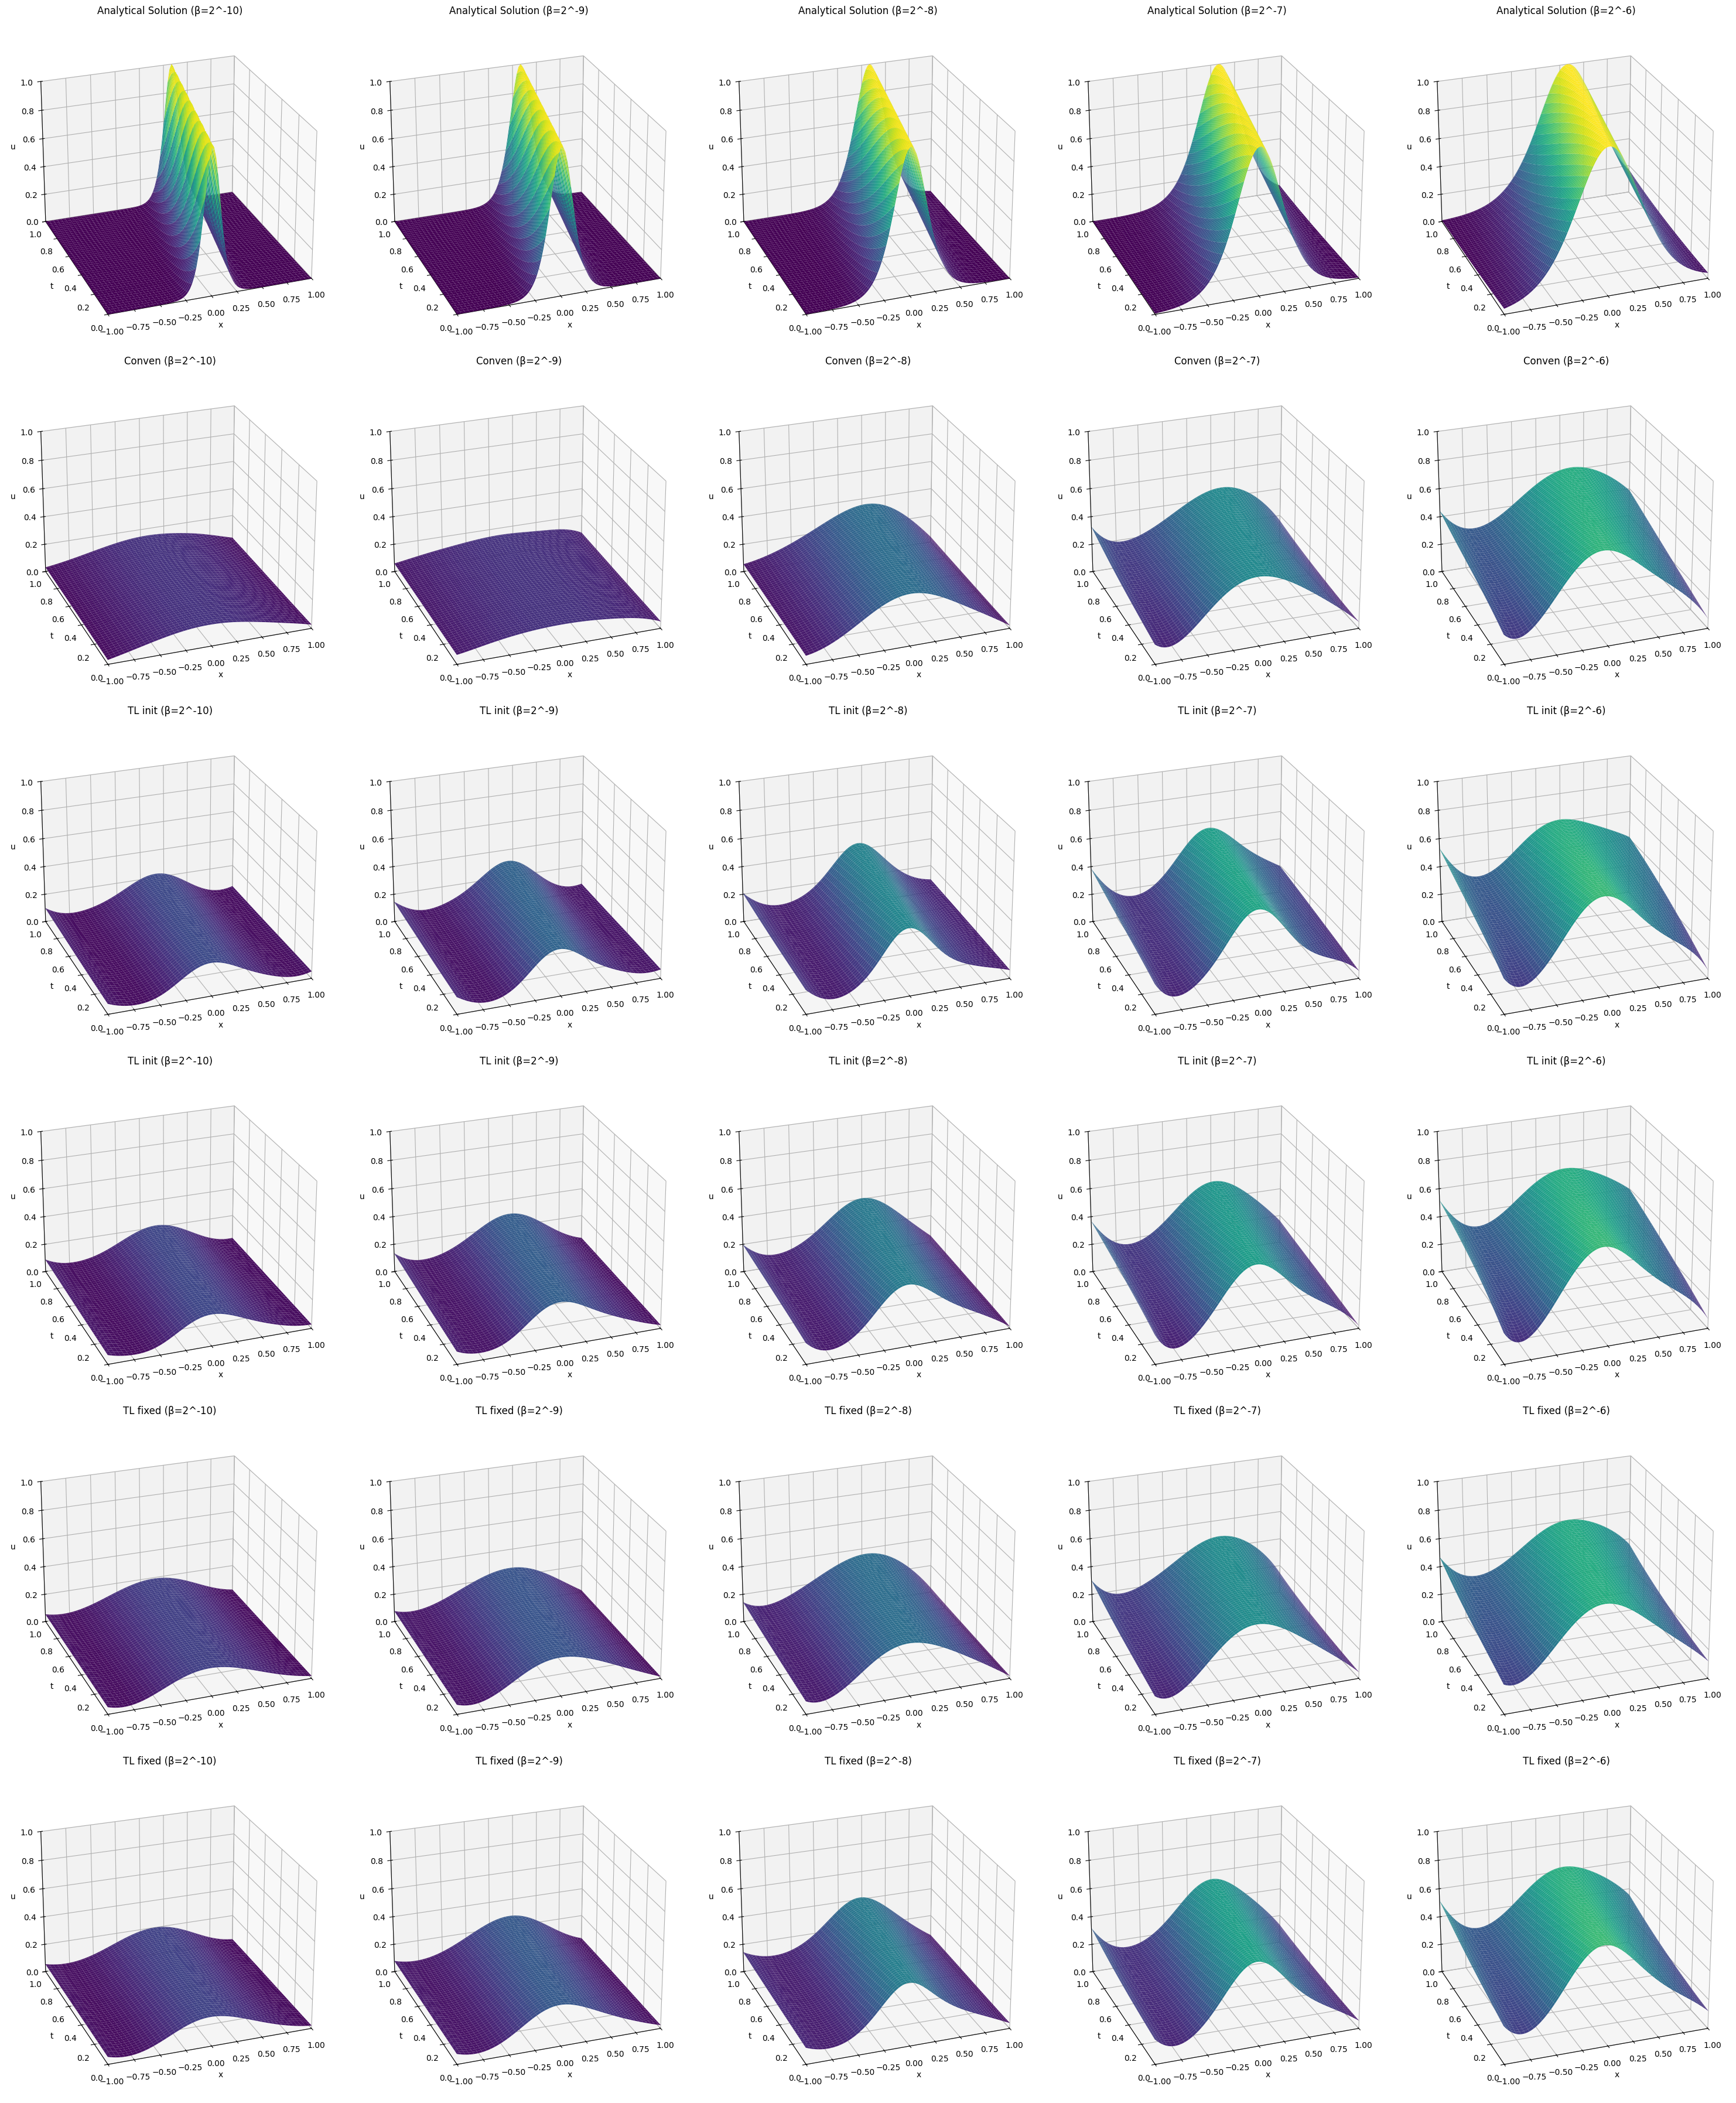

In [15]:
# Number of rows and columns in the grid of plots
row_n = 6
col_n = len(beta_values)

fig = plt.figure(figsize=(col_n * 6, row_n * 6))

print(w_phy, num_epochs)

# Plot the analytical and predicted solutions for each beta value
for i, beta in enumerate(beta_values, start=1):
    # Analytical solution
    ax = fig.add_subplot(row_n, col_n, i, projection='3d')
    ax.plot_surface(
        x_grid.numpy(),
        t_grid.numpy(),
        ana_sols[beta].numpy(),
        cmap='viridis',
        vmin=0,
        vmax=1,
    )
    ax.set_title(f'Analytical Solution (β=2^{int(np.log2(beta))})')
    ax.set_xlabel('x')
    ax.set_ylabel('t')
    ax.set_zlabel('u')
    ax.view_init(elev=25, azim=250)
    ax.set_xlim(x_bound_t_low, x_bound_t_up)
    ax.set_ylim(t_bound_t_low, t_bound_t_up)
    ax.set_zlim(0, 1)


for i, beta in enumerate(beta_values, start=1):
    ax = fig.add_subplot(row_n, col_n, i+col_n, projection='3d')
    ax.plot_surface(
        x_grid.numpy(),
        t_grid.numpy(),
        conv_preds[beta].numpy(),
        cmap='viridis',
        vmin=0,
        vmax=1,
    )
    ax.set_title(f'Conven (β=2^{int(np.log2(beta))})')
    ax.set_xlabel('x')
    ax.set_ylabel('t')
    ax.set_zlabel('u')
    ax.view_init(elev=25, azim=250)
    ax.set_xlim(x_bound_t_low, x_bound_t_up)
    ax.set_ylim(t_bound_t_low, t_bound_t_up)
    ax.set_zlim(0, 1)


for i, beta in enumerate(beta_values, start=1):
    ax = fig.add_subplot(row_n, col_n, i+(2*col_n), projection='3d')
    ax.plot_surface(
        x_grid.numpy(),
        t_grid.numpy(),
        TL_init_preds_6[beta].numpy(),
        cmap='viridis',
        vmin=0,
        vmax=1,
    )
    ax.set_title(f'TL init (β=2^{int(np.log2(beta))})')
    ax.set_xlabel('x')
    ax.set_ylabel('t')
    ax.set_zlabel('u')
    ax.view_init(elev=25, azim=250)
    ax.set_xlim(x_bound_t_low, x_bound_t_up)
    ax.set_ylim(t_bound_t_low, t_bound_t_up)
    ax.set_zlim(0, 1)

for i, beta in enumerate(beta_values, start=1):
    ax = fig.add_subplot(row_n, col_n, i+(3*col_n), projection='3d')
    ax.plot_surface(
        x_grid.numpy(),
        t_grid.numpy(),
        TL_fixed_preds_6[beta].numpy(),
        cmap='viridis',
        vmin=0,
        vmax=1,
    )
    ax.set_title(f'TL init (β=2^{int(np.log2(beta))})')
    ax.set_xlabel('x')
    ax.set_ylabel('t')
    ax.set_zlabel('u')
    ax.view_init(elev=25, azim=250)
    ax.set_xlim(x_bound_t_low, x_bound_t_up)
    ax.set_ylim(t_bound_t_low, t_bound_t_up)
    ax.set_zlim(0, 1)


for i, beta in enumerate(beta_values, start=1):
    ax = fig.add_subplot(row_n, col_n, i+(4*col_n), projection='3d')
    ax.plot_surface(
        x_grid.numpy(),
        t_grid.numpy(),
        MTL_preds[beta].numpy(),
        cmap='viridis',
        vmin=0,
        vmax=1,
    )
    ax.set_title(f'TL fixed (β=2^{int(np.log2(beta))})')
    ax.set_xlabel('x')
    ax.set_ylabel('t')
    ax.set_zlabel('u')
    ax.view_init(elev=25, azim=250)
    ax.set_xlim(x_bound_t_low, x_bound_t_up)
    ax.set_ylim(t_bound_t_low, t_bound_t_up)
    ax.set_zlim(0, 1)

for i, beta in enumerate(beta_values, start=1):
    ax = fig.add_subplot(row_n, col_n, i+(5*col_n), projection='3d')
    ax.plot_surface(
        x_grid.numpy(),
        t_grid.numpy(),
        meta_preds[beta].numpy(),
        cmap='viridis',
        vmin=0,
        vmax=1,
    )
    ax.set_title(f'TL fixed (β=2^{int(np.log2(beta))})')
    ax.set_xlabel('x')
    ax.set_ylabel('t')
    ax.set_zlabel('u')
    ax.view_init(elev=25, azim=250)
    ax.set_xlim(x_bound_t_low, x_bound_t_up)
    ax.set_ylim(t_bound_t_low, t_bound_t_up)
    ax.set_zlim(0, 1)
    

plt.tight_layout()
plt.show()

findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


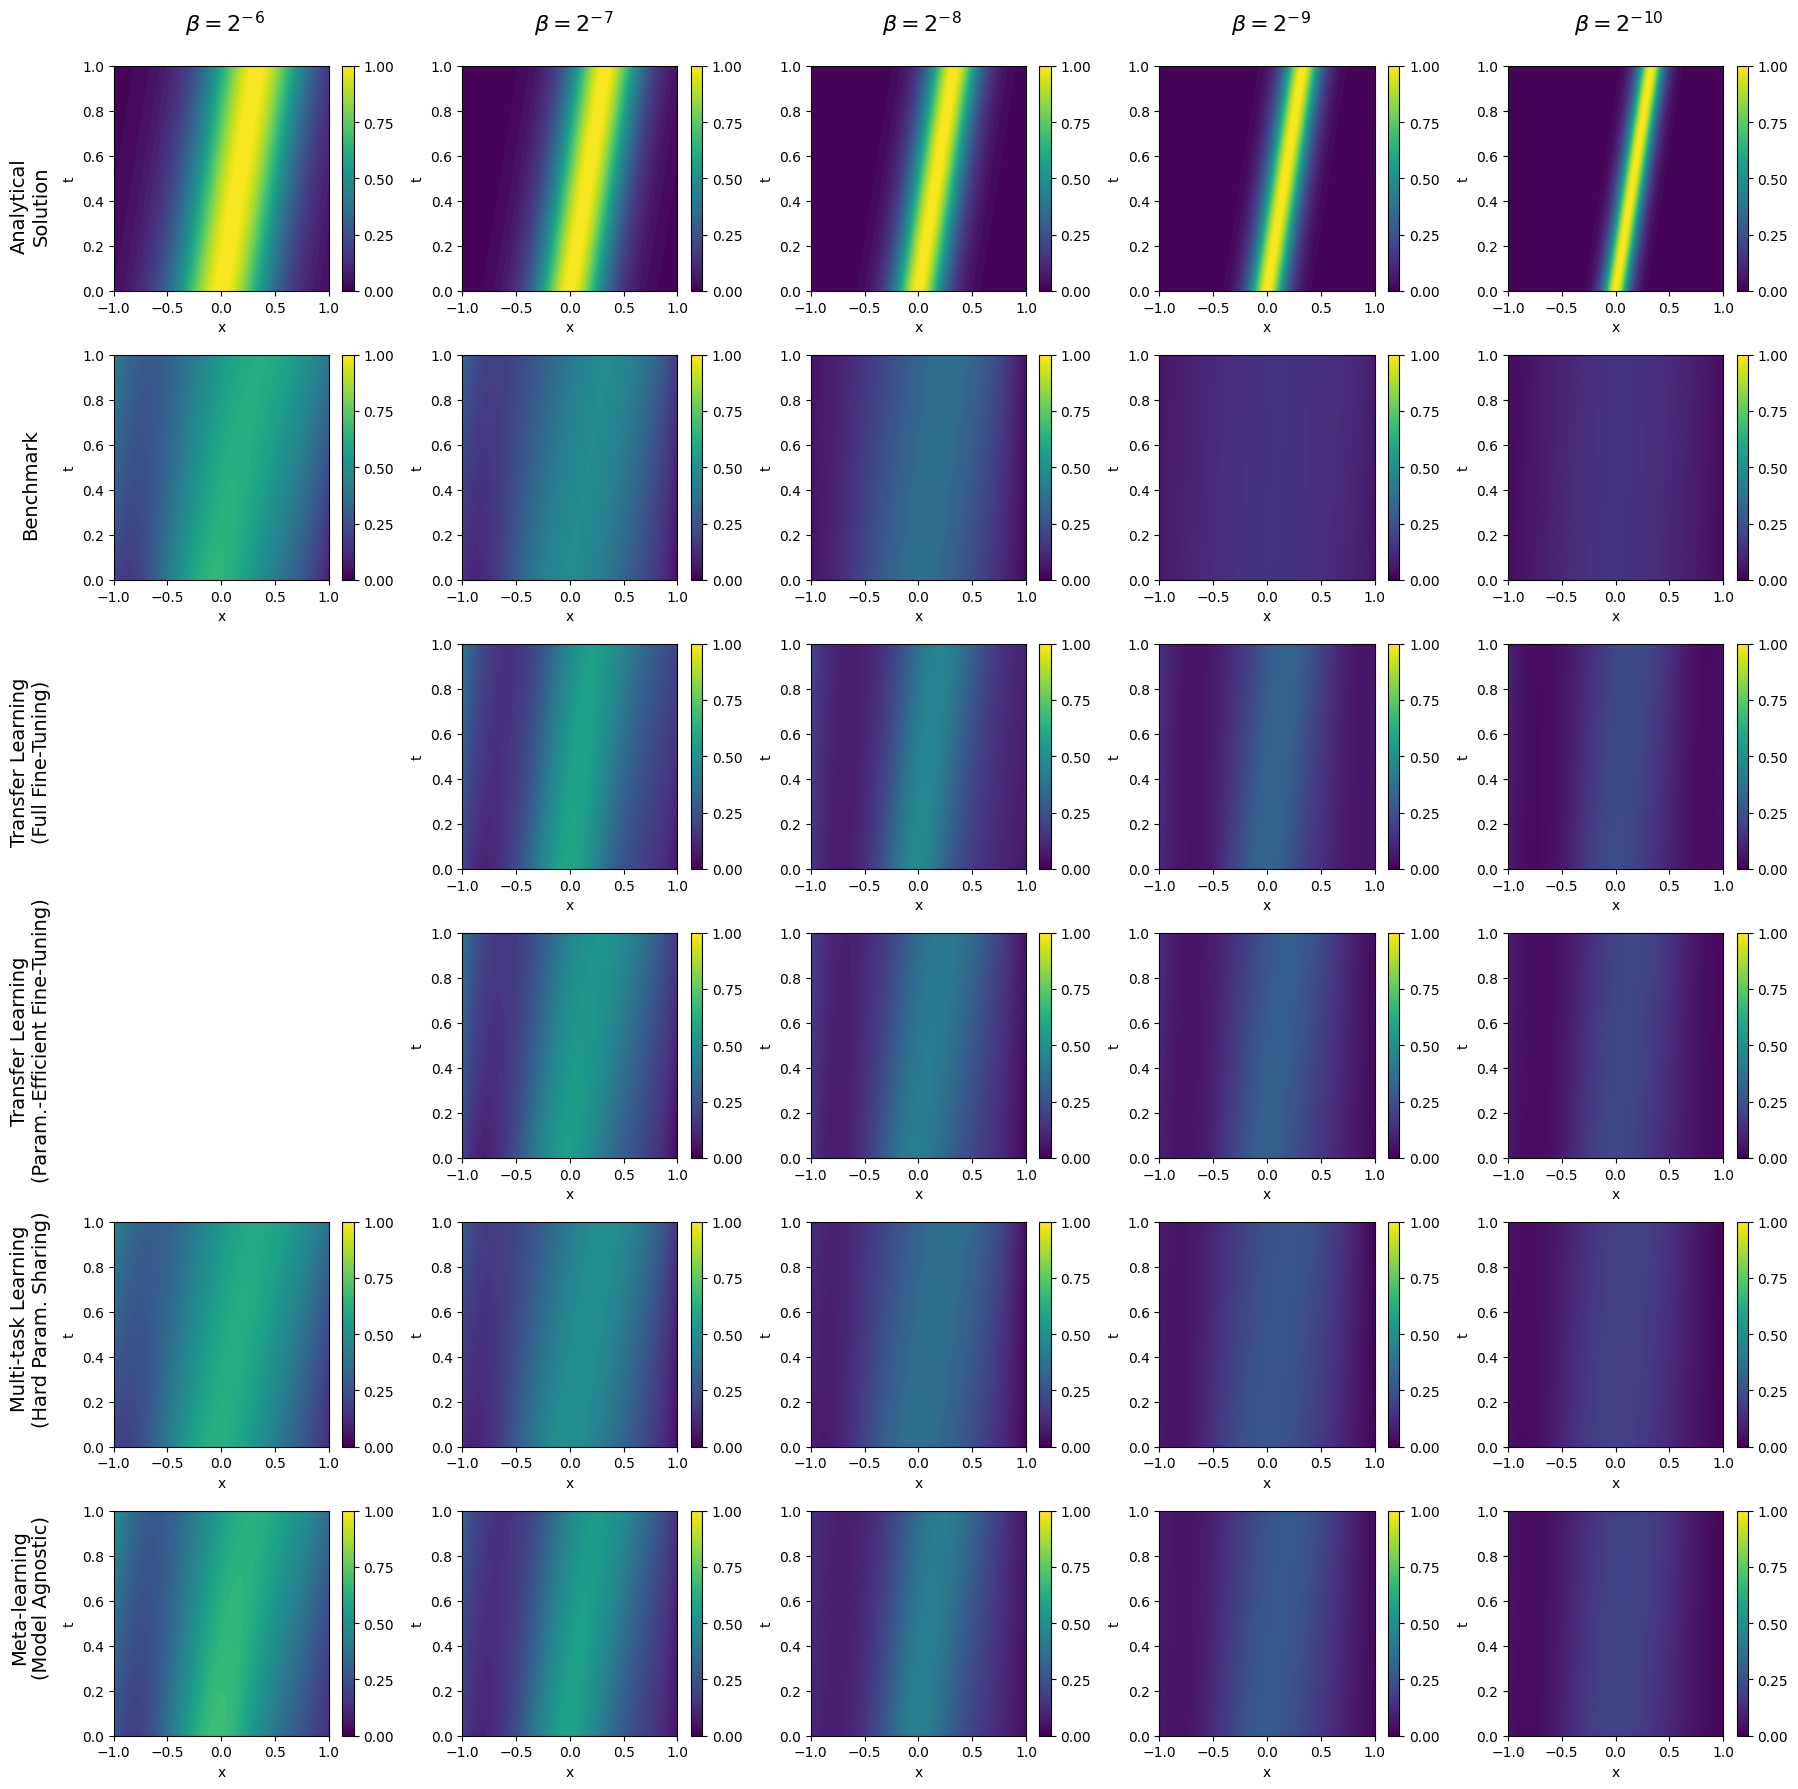

In [16]:
beta_values = beta_values[::-1]

fig = plt.figure(figsize=(col_n * 3.7, row_n * 3))

# Add row titles
row_titles = [
    "Analytical\nSolution",
    "Benchmark",
    "Transfer Learning\n(Full Fine-Tuning)",
    "Transfer Learning\n(Param.-Efficient Fine-Tuning)",
    "Multi-task Learning\n(Hard Param. Sharing)",
    "Meta-learning\n(Model Agnostic)"
]
for i, row_title in enumerate(row_titles, start=1):
    plt.text(
        x=-0.05,  # Position to the left of the plot
        y=1 - (i - 0.5) / row_n,
        s=row_title,
        fontsize=14,
        va='center',
        ha='center',
        rotation='vertical'
    )
plt.axis('off')

# Loop through each subplot and add solutions
plot_titles = [r' $β = 2^{' + f'{int(np.log2(beta))}' + r'}$' + '\n' for beta in beta_values]
solutions = [
    (ana_sols, "Analytical Solution"),
    (conv_preds, "Benchmark"),
    (TL_init_preds_6, "Transfer Learning\n(Initialisation)"),
    (TL_fixed_preds_6, "Transfer Learning\n(Fixed)"),
    (MTL_preds, "MTL\n(Hard Param. Sharing)"),
    (meta_preds, "Meta-learning\n(Model Agnostic)"),
]

for row, (data_dict, row_title) in enumerate(solutions):
    for col, beta in enumerate(beta_values):
        if beta == 2**-6 and row_title[0] == 'T':
            continue

        ax = fig.add_subplot(row_n, col_n, row * col_n + col + 1)
        im = ax.contourf(
            x_grid.numpy(),
            t_grid.numpy(),
            data_dict[beta].numpy(),
            levels=50,
            cmap='viridis',
            vmin=0,
            vmax=1
        )
        fig.colorbar(
            plt.cm.ScalarMappable(norm=im.norm, cmap=im.cmap),
            ax=ax,
            ticks=[0, 0.25, 0.5, 0.75, 1]
        )
        ax.set_xlabel('x')
        ax.set_ylabel('t')
        
        if row == 0:  # Add titles to the top row
            ax.set_title(plot_titles[col], fontsize=16)

plt.tight_layout()
plt.show()

### Relative $L_2$

In [39]:
def relative_l2_loss(analytical, predicted):
    return np.linalg.norm(analytical - predicted) / np.linalg.norm(analytical)

In [43]:
L2_df = pd.DataFrame()
L2_df['β'] = [int(np.log2(beta)) for beta in beta_values]


L2_df['conventional'] = [relative_l2_loss(ana_sols[beta], conv_preds[beta]) for beta in beta_values]
L2_df['TL_fixed_6'] = [relative_l2_loss(ana_sols[beta], TL_fixed_preds_6[beta]) for beta in beta_values]
#L2_df['TL_fixed_10'] = [relative_l2_loss(ana_sols[beta], TL_fixed_preds_10[beta]) for beta in beta_values]
L2_df['TL_init_6'] = [relative_l2_loss(ana_sols[beta], TL_init_preds_6[beta]) for beta in beta_values]
#L2_df['TL_init_10'] = [relative_l2_loss(ana_sols[beta], TL_init_preds_10[beta]) for beta in beta_values]
L2_df['MTL'] = [relative_l2_loss(ana_sols[beta], MTL_preds[beta]) for beta in beta_values]
L2_df['meta'] = [relative_l2_loss(ana_sols[beta], meta_preds[beta]) for beta in beta_values]

display(L2_df)

,β,conventional,TL_fixed_6,TL_init_6,MTL,meta
0,-10,0.856400,0.783361,0.772508,0.811397,0.801814
1,-9,0.842717,0.693399,0.674093,0.732680,0.712127
2,-8,0.631969,0.575389,0.542275,0.628491,0.563327
3,-7,0.519804,0.462971,0.441559,0.501480,0.434284
4,-6,0.381800,0.385814,0.390960,0.394130,0.369737
